# Section 00 - Getting ready

In [7]:
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns

----

# Section 01 - Plot types

1. shows distribution and quantiles, especially useful when comparing uni-modal distributions.
        
        boxplot

2. highlights individual values, supports comparison and can show rankings or deviations categories
and totals

        bar chart

3. shows overall changes and patterns, usually over intervals of time

        line chart

4. shows relationship between two continuous variables.

        scatterplot


-----

# Section 02 - Reproducing a plot with plotnine


1. Reproduce the following visualization of the association between the variables cty and hwy for the
years 1999 and 2008 from the dataset mpg using the library plotnine.

<img src = '../images/Ekran Resmi 2026-02-08 16.03.48.png' width = 500>

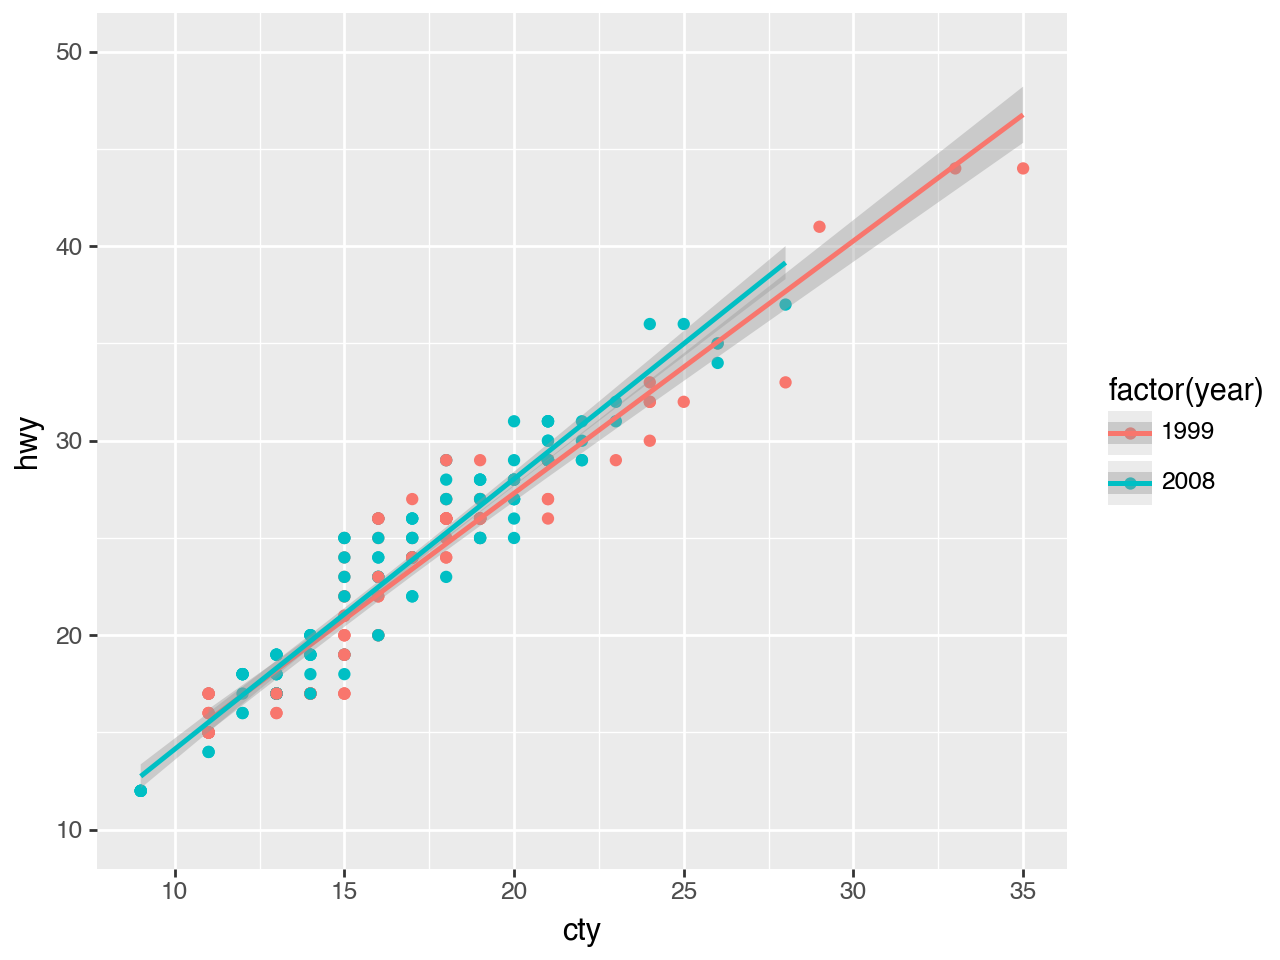

In [26]:
from plotnine.data import mpg

df = mpg[mpg['year'].isin([1999, 2008])][['cty','hwy', 'year']]
df['year'] = df['year'].astype('category')

(
    ggplot(df, aes(x = 'cty', y = 'hwy', color = 'year')) +
    geom_point() +
    stat_smooth(method = 'lm') +
    scale_y_continuous(limits=(10, 50)) + 
    labs(color = 'factor(year)')
)


------

# Section 03 - Visualizing distributions 

Iris is a classical dataset in machine learning literature. It was first introduced by R.A. Fisher in his
1936 paper.

1. Load the iris data and transform it to a pandas.DataFrame. Have a look at its first and last rows.
Hint: load the dataset from sklearn.datasets. Hint: Set the datatype of the column species to str.

In [29]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)['frame']

iris['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
for s in iris['target']]

iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
['setosa' if s == 0 else
 'versicolor' if s == 1 else
 'virginica'
 for s in iris['target']]

print('')

2. How are the lengths and widths of sepals and petals distributed? Make one plot of the distributions
with multiple facets. Hint: You will need to reshape your data so that the different measurements (petal
length, sepal length, etc.) are in one column and the values in another. Remember which is the best plot
for visualizing distributions.

,target,media,measurement (cm)
0,setosa,sepal length (cm),5.1
1,setosa,sepal length (cm),4.9
2,setosa,sepal length (cm),4.7
3,setosa,sepal length (cm),4.6
4,setosa,sepal length (cm),5.0


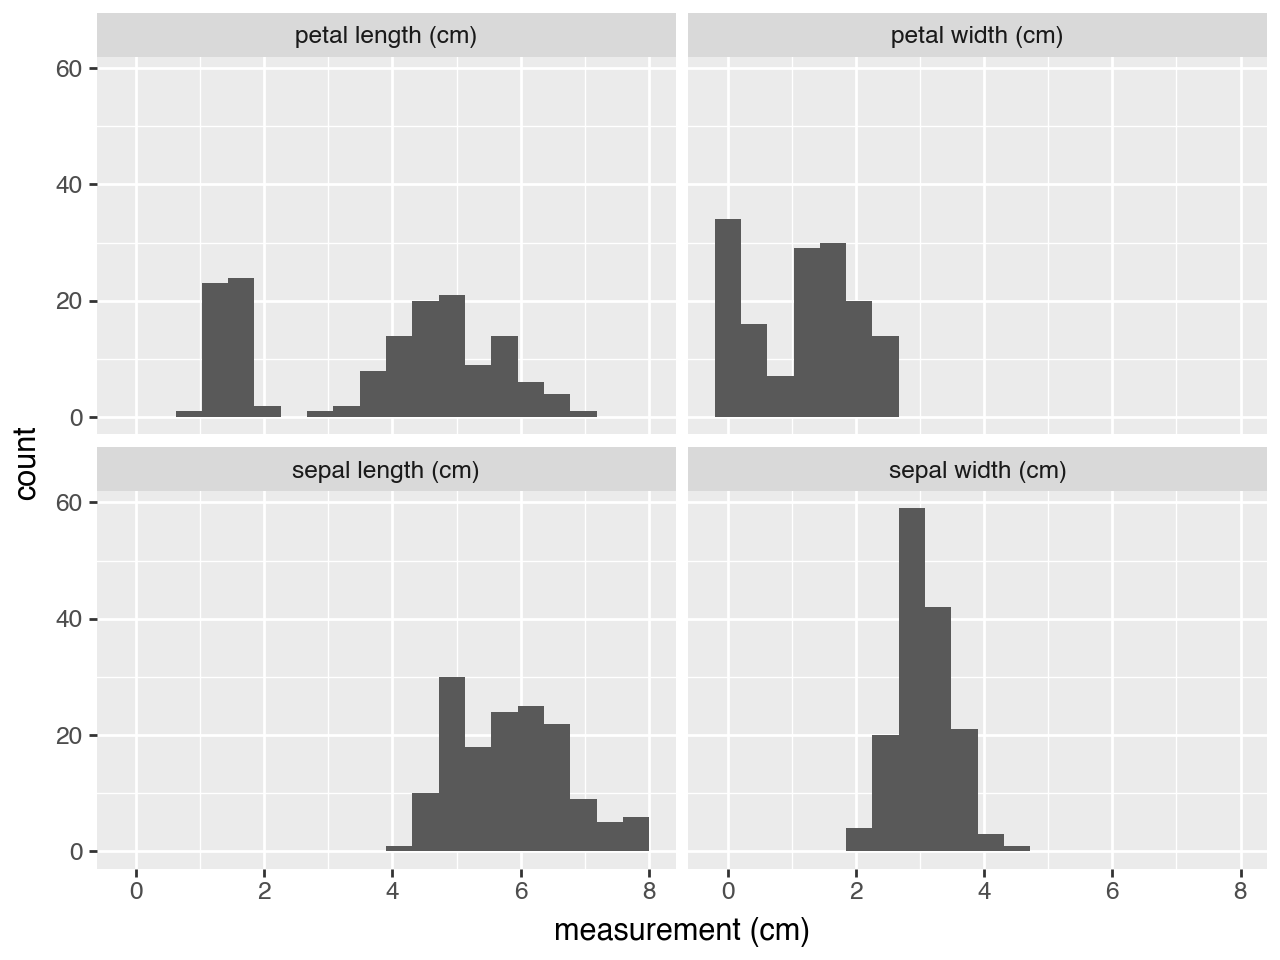

In [48]:
iris_dist = iris.melt(id_vars= 'target', var_name= 'media', value_name= 'measurement (cm)')
display(iris_dist.head())

(
    ggplot(iris_dist, aes('measurement (cm)')) + 
    geom_histogram(bins = 20) +
    facet_wrap('~media')
)

4. Visualize the lengths and widths of the sepals and petals from the iris data with boxplots

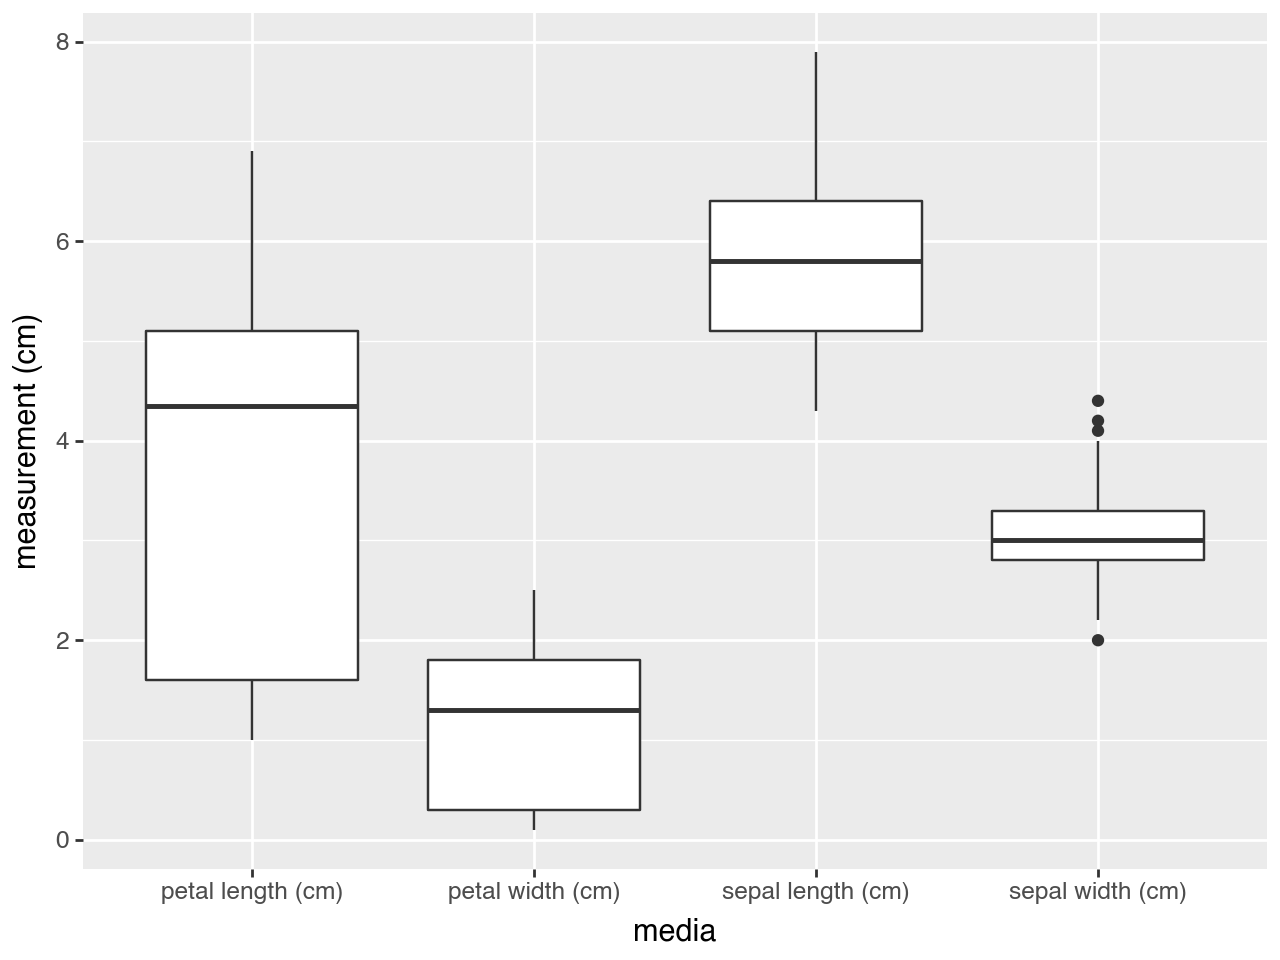

In [49]:
(
    ggplot(iris_dist, aes(x = 'media', y = 'measurement (cm)')) +
    geom_boxplot()
)

5. Add individual data points as dots on the boxplots to visualize all points. Discuss: in this case, why is
it not good to visualize the data with boxplots? Hint: geom_jitter()

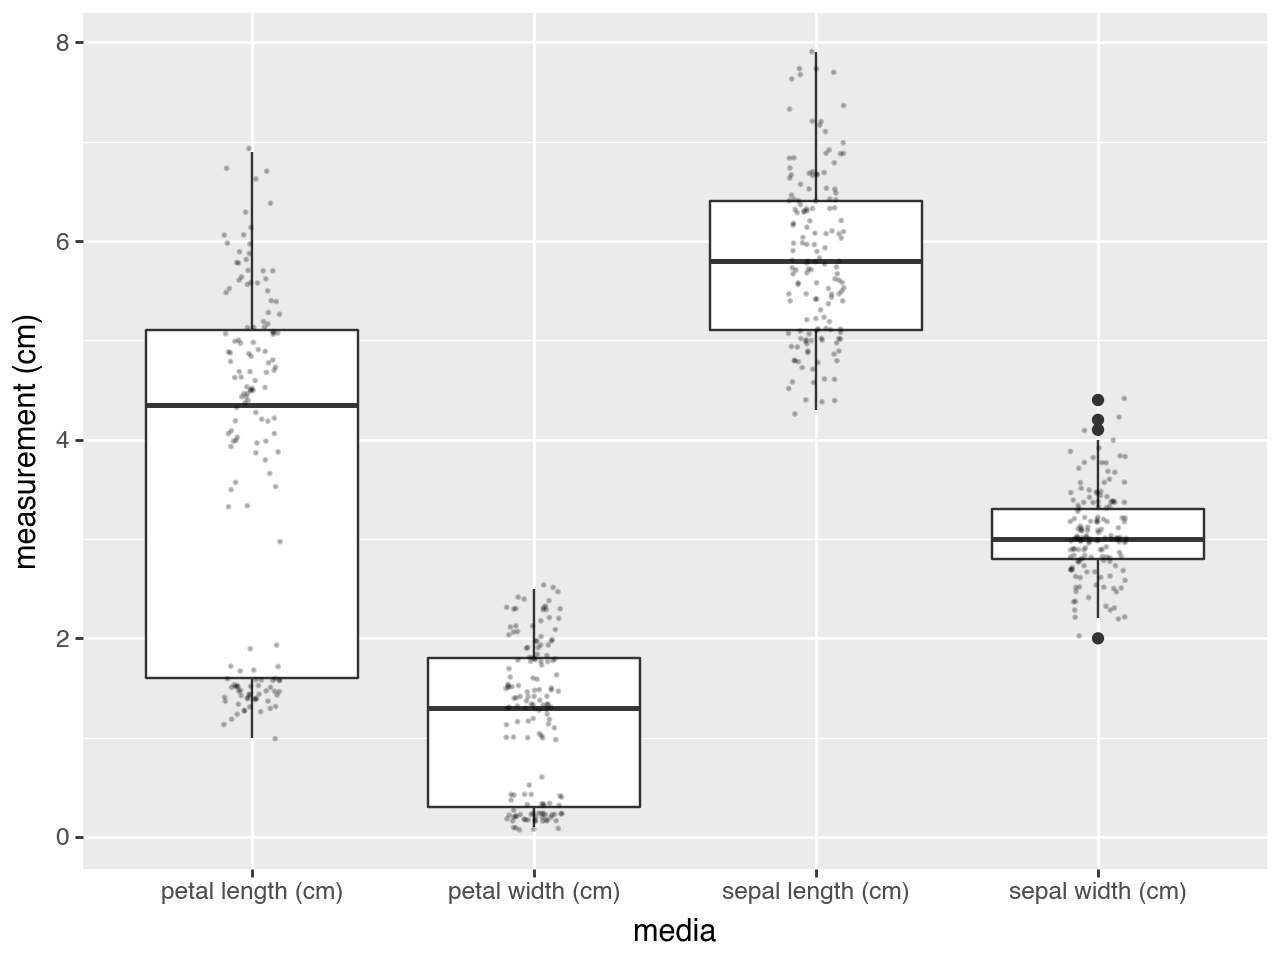

In [58]:
(
    ggplot(iris_dist, aes(x = 'media', y = 'measurement (cm)'))+
    geom_boxplot() + 
    geom_jitter(width = 0.1, size = 0.2, alpha = 0.2)
)

6. Alternatives to boxplot are violin plots (geom_violin()). Try combining a boxplot with a violinplot
to show the lengths and widths of the sepals and petals from the iris data.

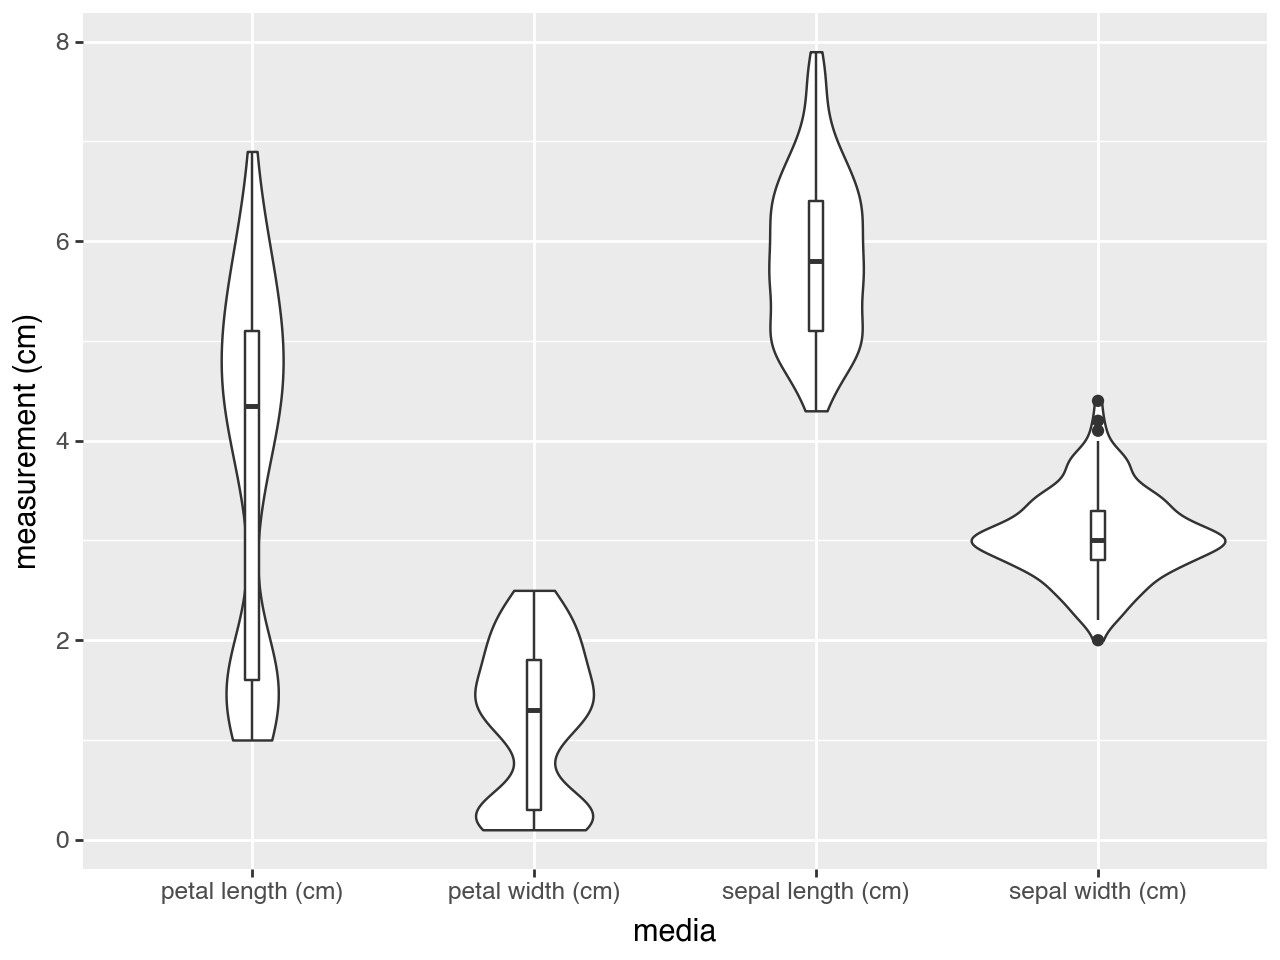

In [70]:
(
    ggplot(iris_dist, aes(x = 'media', y = 'measurement (cm)')) +
    geom_violin() + 
    geom_boxplot(width = 0.05) 
    # geom_jitter(width = 0.1, size = 0.1, alpha = 0.1)
)

------
# Section 04 - Visualizing relationships between continuous variables

1. Are there any relationships/correlations between petal length and width? How would you visually
show it?

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


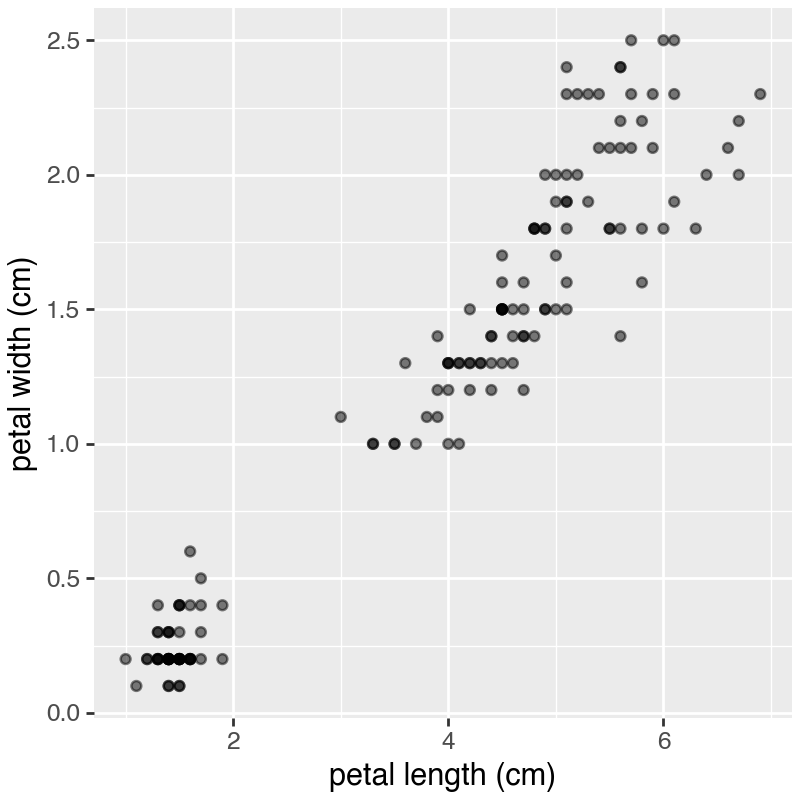

In [101]:
display(iris.head())

(
    ggplot(iris, aes(x = 'petal length (cm)', y = 'petal width (cm)')) + 
    geom_point(alpha = 0.5) +
    theme(figure_size= (4,4))
)

2. Do petal lengths and widths correlate in every species? Show this with a plot.

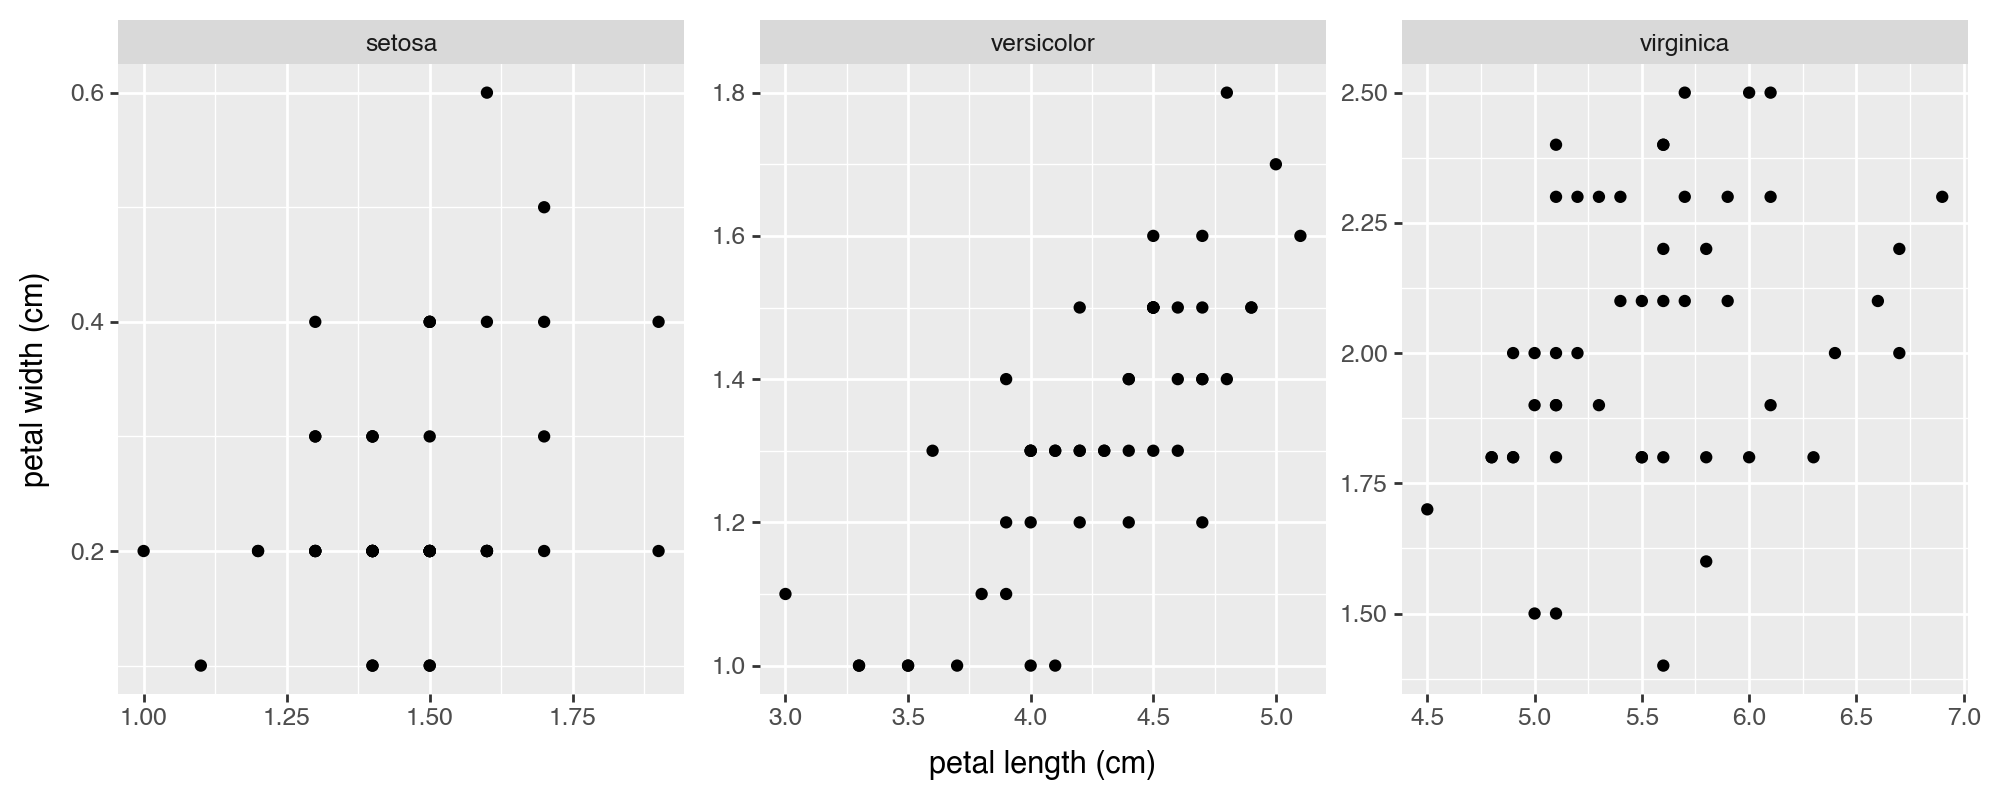

In [111]:
(
    ggplot(iris, aes (x = 'petal length (cm)', y = 'petal width (cm)')) +
    geom_point() + 
    facet_wrap('~target', scales= 'free') +
    theme(figure_size=(10,4))
)

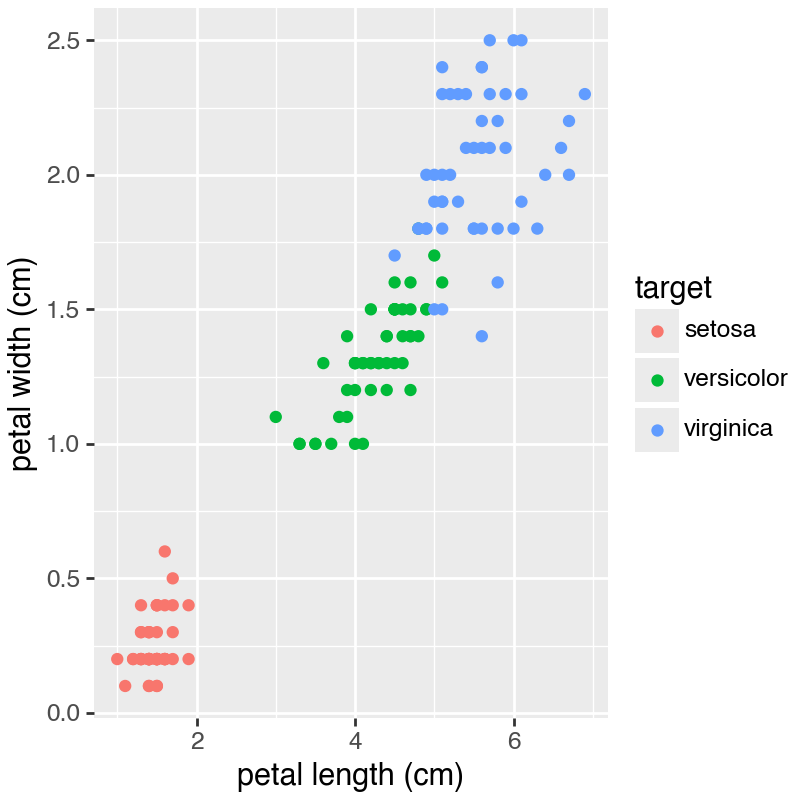

In [108]:
(
    ggplot(iris, aes (x = 'petal length (cm)', y = 'petal width (cm)',  color = 'target')) +
    geom_point() + 
    theme(figure_size=(4,4))
)

---------

# Section 05 - Quantile-Quantile plots

We will simulate some data from different distributions and will compare their quantile-quantile plots.

1. We will use a standard normal ($\mu = 0$ and $\sigma^2 = 1$) distribution as a reference set. simulate 100 draws
from a standard normal distribution. Add them as a column to a data table and plot a histogram of these
values. 

Next, use plotnine to create a QQ-plot comparing the expected against the observed quantiles.
Use geom_abline to draw a line on the QQ-plot where the data should be if the observed and expected
quantiles match exactly. (Do not mind warnings, if any).

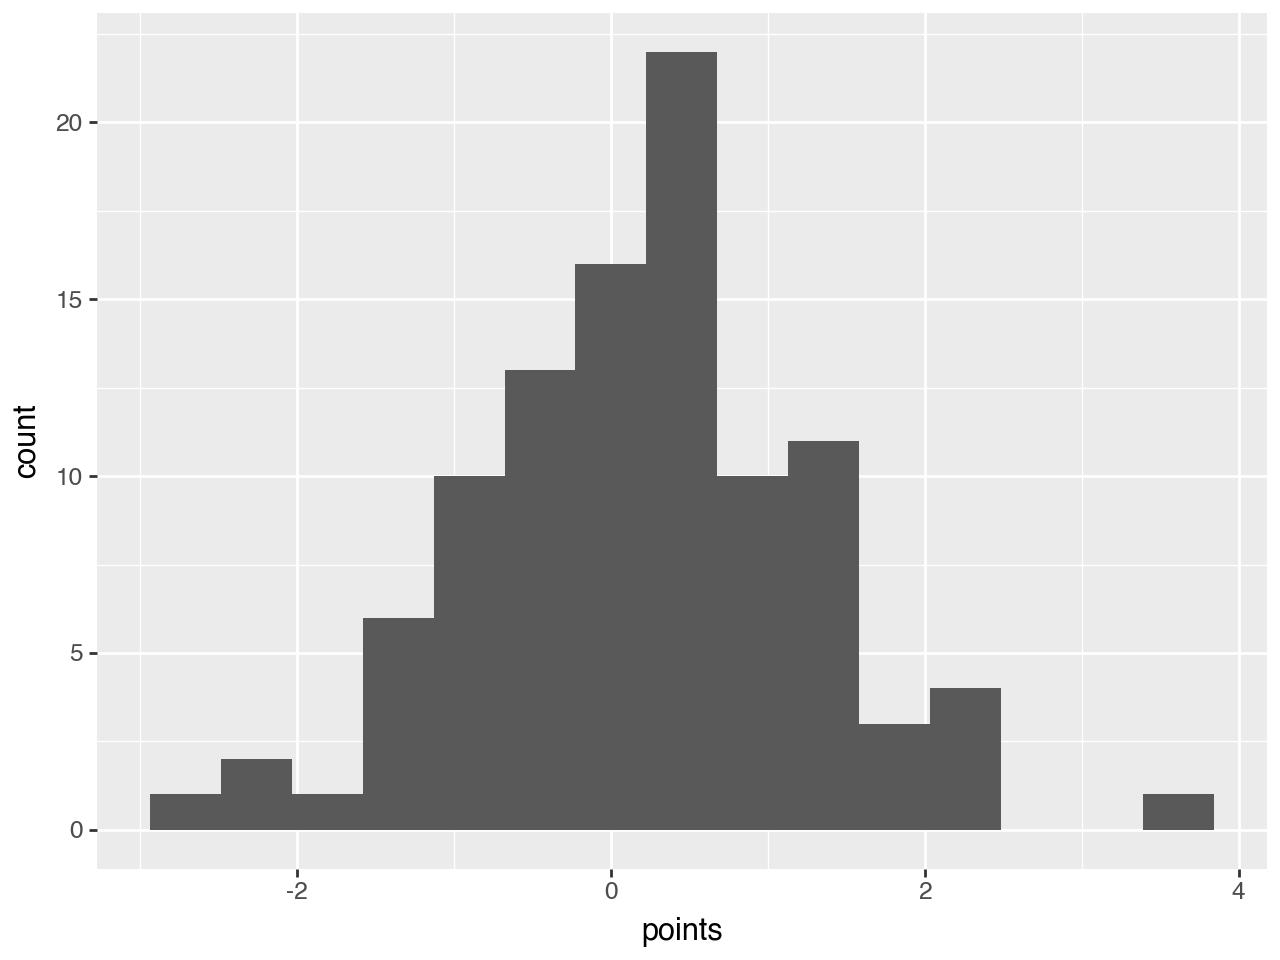

In [145]:
np.random.seed(525)

points = np.random.normal(loc = 0, scale = 1, size = 100)
dt = pd.DataFrame({'points':points})

(
    ggplot(dt, aes('points')) +
    geom_histogram(bins = 15)
)

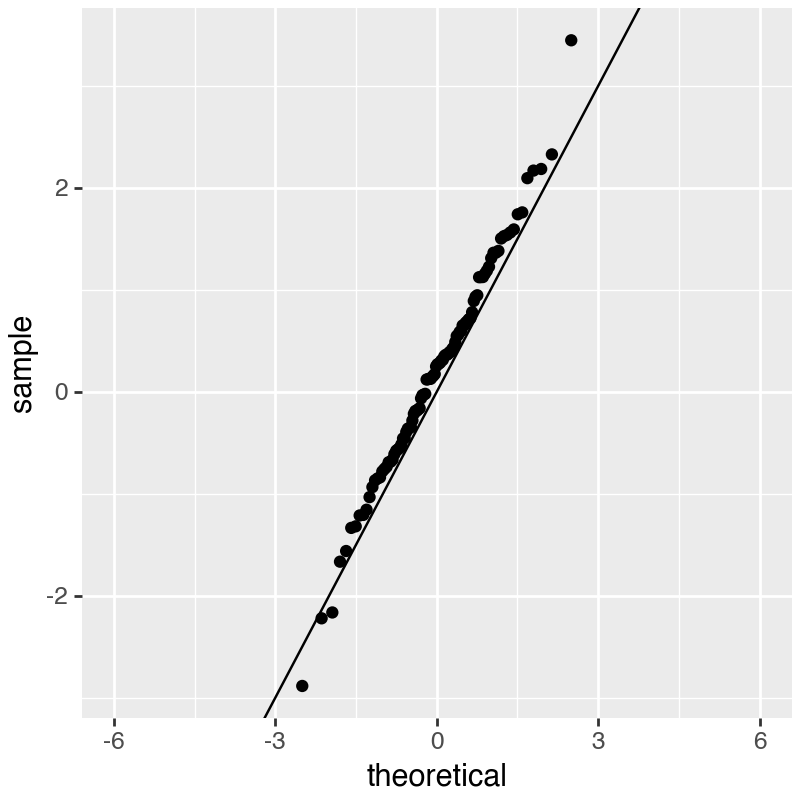

In [146]:
(
    ggplot(dt, aes(sample = 'points')) +
    geom_qq() + 
    geom_abline(slope = 1, intercept = 0) + 
    xlim(-6,6) + 
    theme(figure_size=(4,4))
)

2. Now add a normal distribution with $\mu = 4$ to your pandas.DataFrame and plot the Q-Q plot. How
did it change?

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_qq : Removed 1 rows containing missing values.


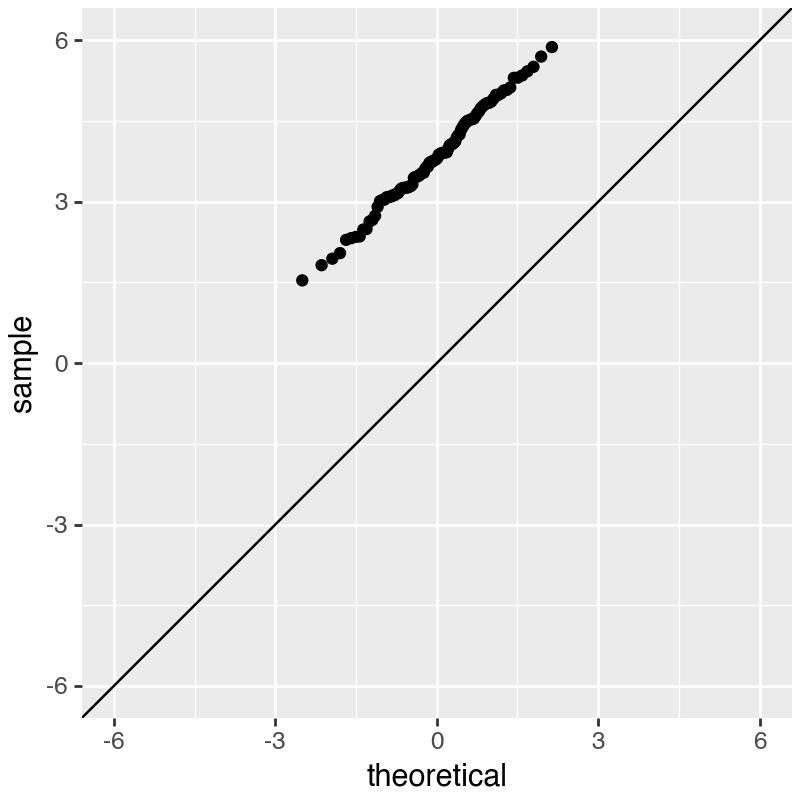

In [147]:
dt_shift = pd.DataFrame({'points':np.random.normal(loc = 4, scale = 1, size = 100)})

(
    ggplot(dt_shift, aes(sample = 'points')) + 
    geom_qq() +
    geom_abline(slope = 1, intercept = 0) +
    xlim(-6,6) + 
    ylim(-6,6) + 
    theme(figure_size= (4,4))
)

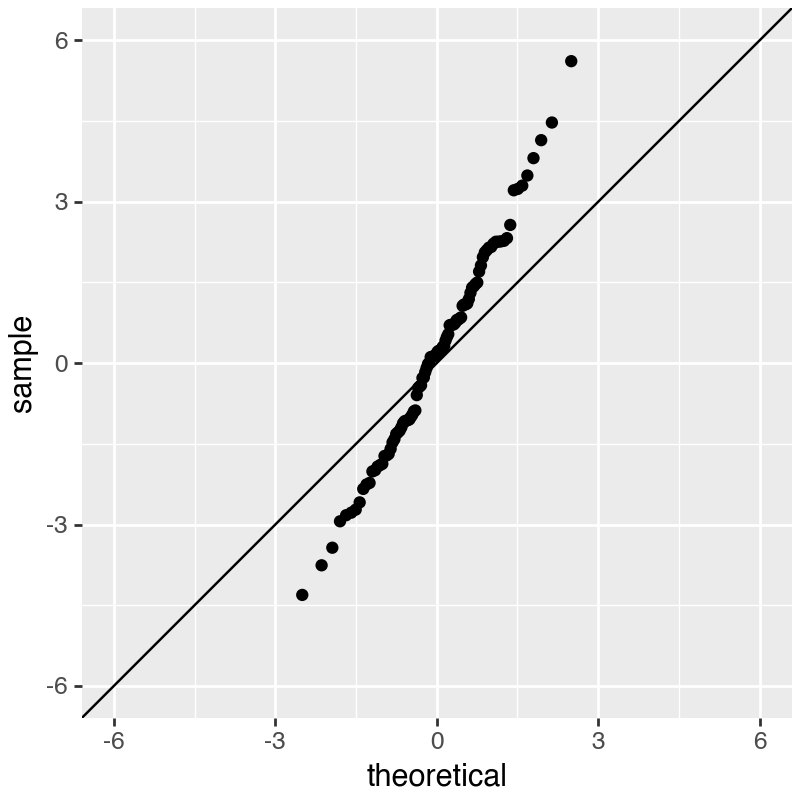

In [150]:
dt_scale = np.random.normal(loc = 0, scale = 2, size = 100)
dt_scale = pd.DataFrame({'points': dt_scale})

(
    ggplot(dt_scale, aes(sample = 'points')) +
    geom_qq() + 
    geom_abline(slope = 1, intercept = 0) + 
    xlim(-6,6) +
    ylim(-6,6) + 
    theme(figure_size=(4,4))   
)

------

# Homework

# Section 06 - Axes scaling and text labeling

1. Load the medals dataset stored in the file medals.csv. 

Plot the total number of medals won against
population size in the 2016 Rio Olympics with a scatter plot. You can load the dataset with the following
code:

In [156]:
dt_medals = pd.read_csv('../Datasets/Exercise2_datasets/extdata 4/medals.csv')

dt_medals.head()

,Unnamed: 0,code,gold,silver,bronze,total,country,population
0,1,USA,46,37,38,121,United States,321418820
1,2,GBR,27,23,17,67,United Kingdom,65138232
2,3,CHN,26,18,26,70,China,1371220000
3,4,RUS,19,18,19,56,Russian Federation,144096812
4,5,DEU,17,10,15,42,Germany,81413145


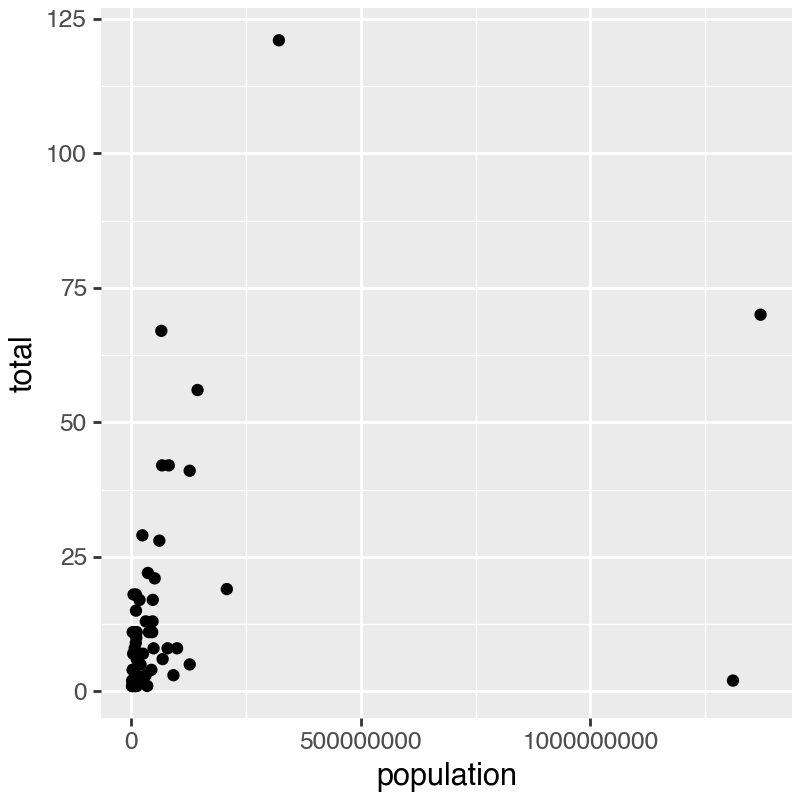

In [158]:
(
    ggplot(dt_medals, aes(x = 'population', y = 'total')) + 
    geom_point() +
    theme(figure_size=(4,4))
)

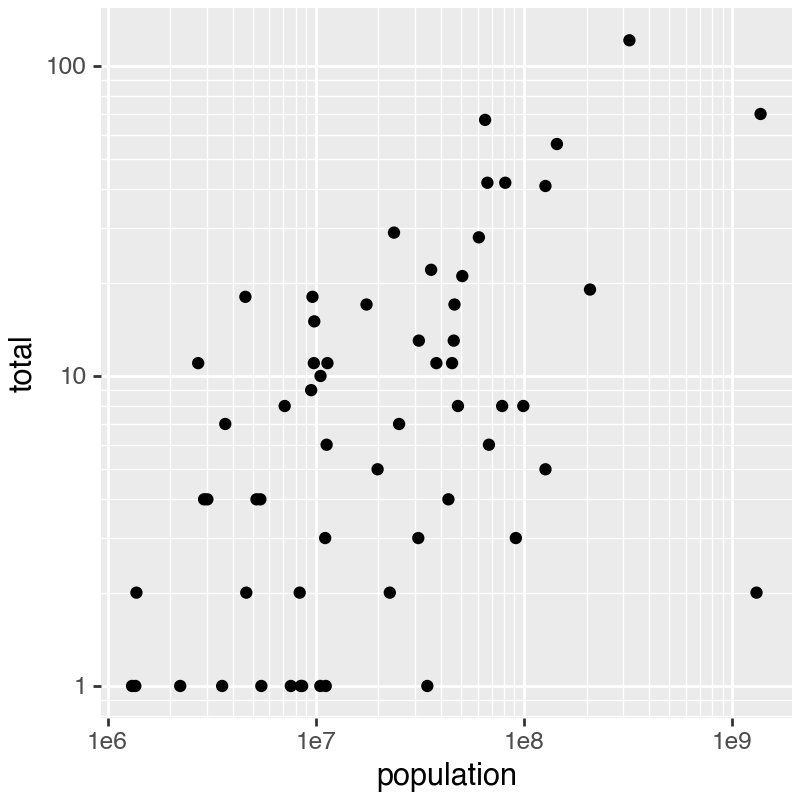

In [160]:
(
    ggplot(dt_medals, aes(x = 'population', y = 'total')) + 
    geom_point() +
    scale_x_log10() +
    scale_y_log10() +
    theme(figure_size=(4,4)) 
)

----
# Section 07 - The importance of data visualization

Anscombe’s quartet was constructed in 1973 by the statistician Francis Anscombe to demonstrate both
the importance of graphing data before analyzing it, and the effect of outliers on statistical properties

1. Look at the dataset anscombe. Is it tidy?

In [163]:
anscombe = sns.load_dataset('anscombe')
anscombe.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


2. Compute the mean and standard deviation of each variable for each group. What do you see?

In [171]:
anscombe.groupby('dataset').agg(
    x_mean = ('x', 'mean'),
    y_mean = ('y', 'mean'),
    x_std  = ('x', 'std'),
    y_std  = ('y', 'std')
).reset_index()

,dataset,x_mean,y_mean,x_std,y_std
0,I,9.0,7.500909,3.316625,2.031568
1,II,9.0,7.500909,3.316625,2.031657
2,III,9.0,7.500000,3.316625,2.030424
3,IV,9.0,7.500909,3.316625,2.030579


3. For each dataset, what is the Pearson correlation between x and y? 
Hint: pandas.DataFrame.corr() and Wikipedia for Pearson correlation.

https://www.wikiwand.com/en/articles/Pearson_correlation_coefficient

In [174]:
correlations = anscombe.groupby('dataset').apply(
    lambda group: pd.Series({'correlation': group['x'].corr(group['y'])})
).reset_index()
correlations

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_97370/1924274548.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,dataset,correlation
0,I,0.816421
1,II,0.816237
2,III,0.816287
3,IV,0.816521


4. Only by computing statistics, we could conclude that all 4 datasets have the same data. Now, plot x
and y for each dataset and discuss.

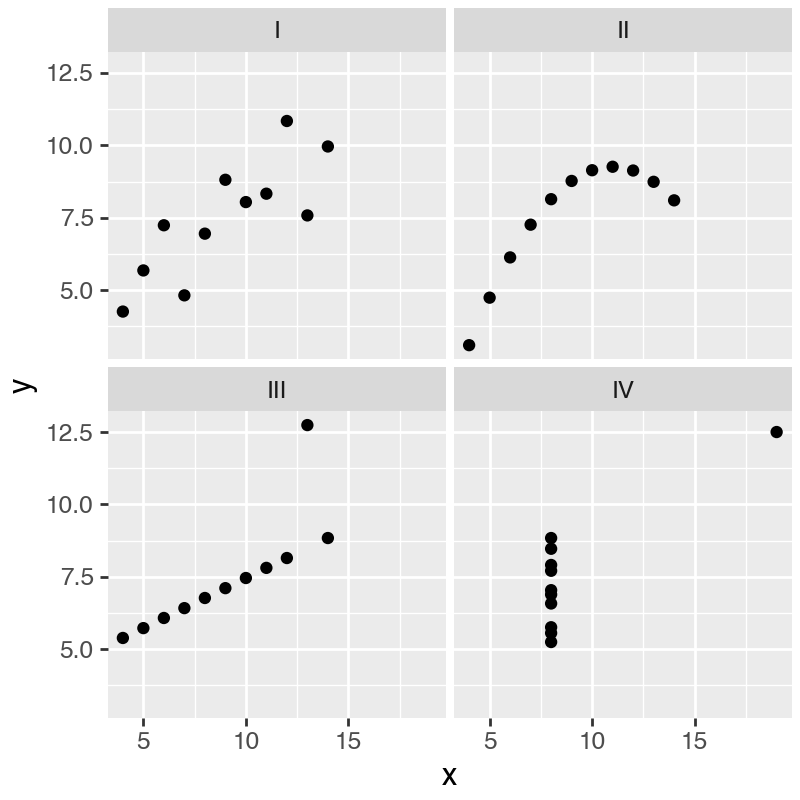

In [177]:
(
    ggplot(anscombe, aes(x = 'x', y = 'y')) + 
    geom_point() + 
    facet_wrap('~dataset') +
    theme(figure_size= (4,4))
)

5. Consider now the datasets given in the file boxplots.csv. Load the data and visualize the different
datasets with a boxplot. What do you observe? What can you conclude?

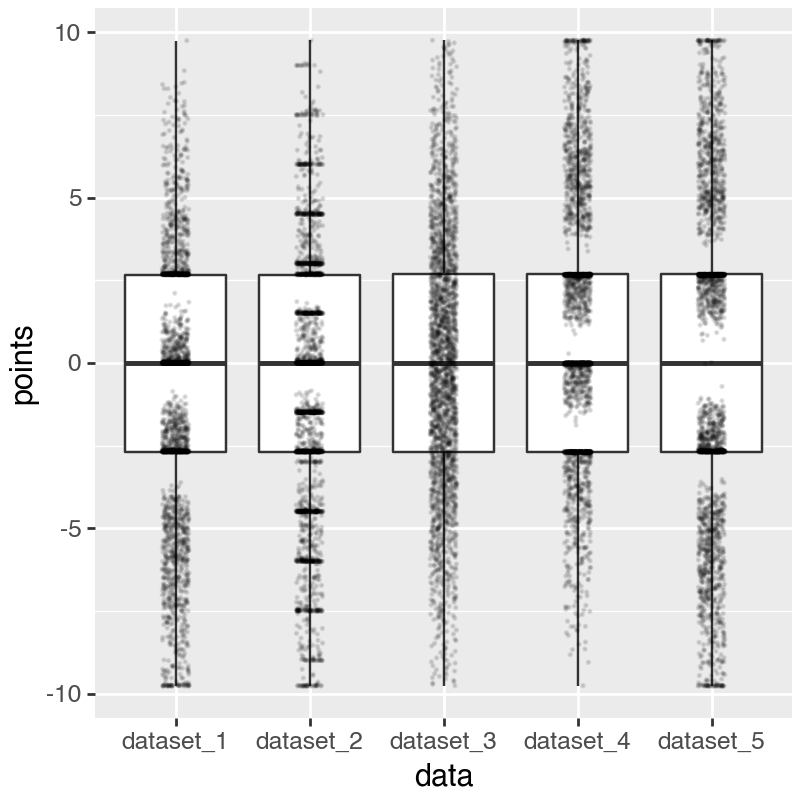

In [188]:
dt_boxplots = pd.read_csv('../Datasets/Exercise2_datasets/extdata 4/boxplots.csv')

dt_boxplots_melt = dt_boxplots.melt(var_name= 'data', value_name= 'points')

(
    ggplot(dt_boxplots_melt, aes(x = 'data', y = 'points')) +
    geom_boxplot() +
    geom_jitter(alpha = 0.1, size = 0.1, width = 0.1) +
    theme(figure_size= (4,4))
)

-------

# Section 08 - Improving a scatter plot

The following scatterplot shows the time spent on social media vs average grades at a university for
10,000 students.

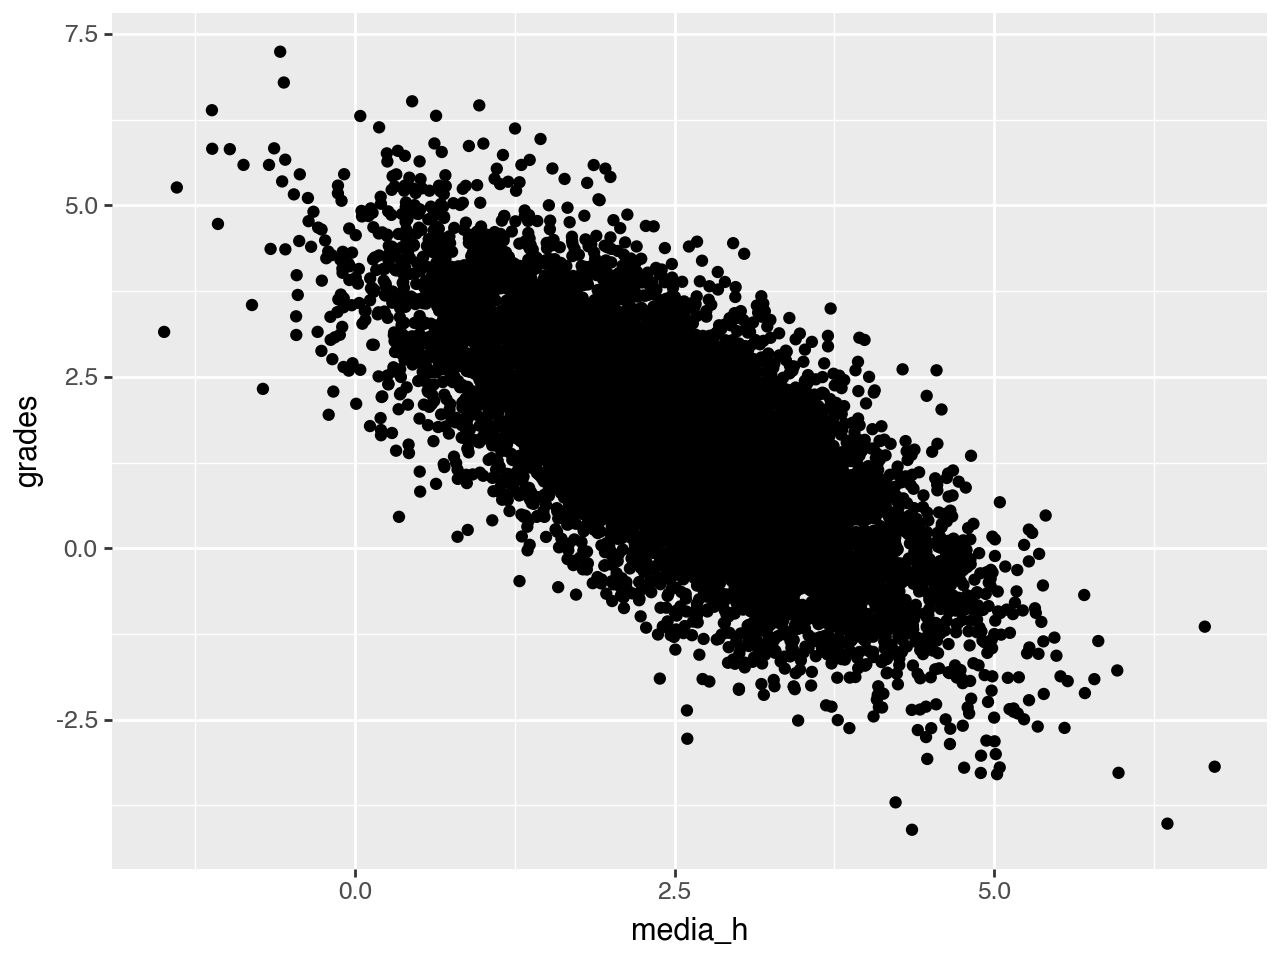

In [215]:
hours_in_social_media = np.random.normal(loc = 2.5, scale = 1, size = 10000)
grades = 4 - hours_in_social_media + np.random.normal(loc = 0, scale = 1, size = 10000)

grade_media = pd.DataFrame({
    'grades' : grades,
    'media_h': hours_in_social_media
})

(
    ggplot(grade_media, aes(x = 'media_h', y = 'grades')) +
    geom_point()
)

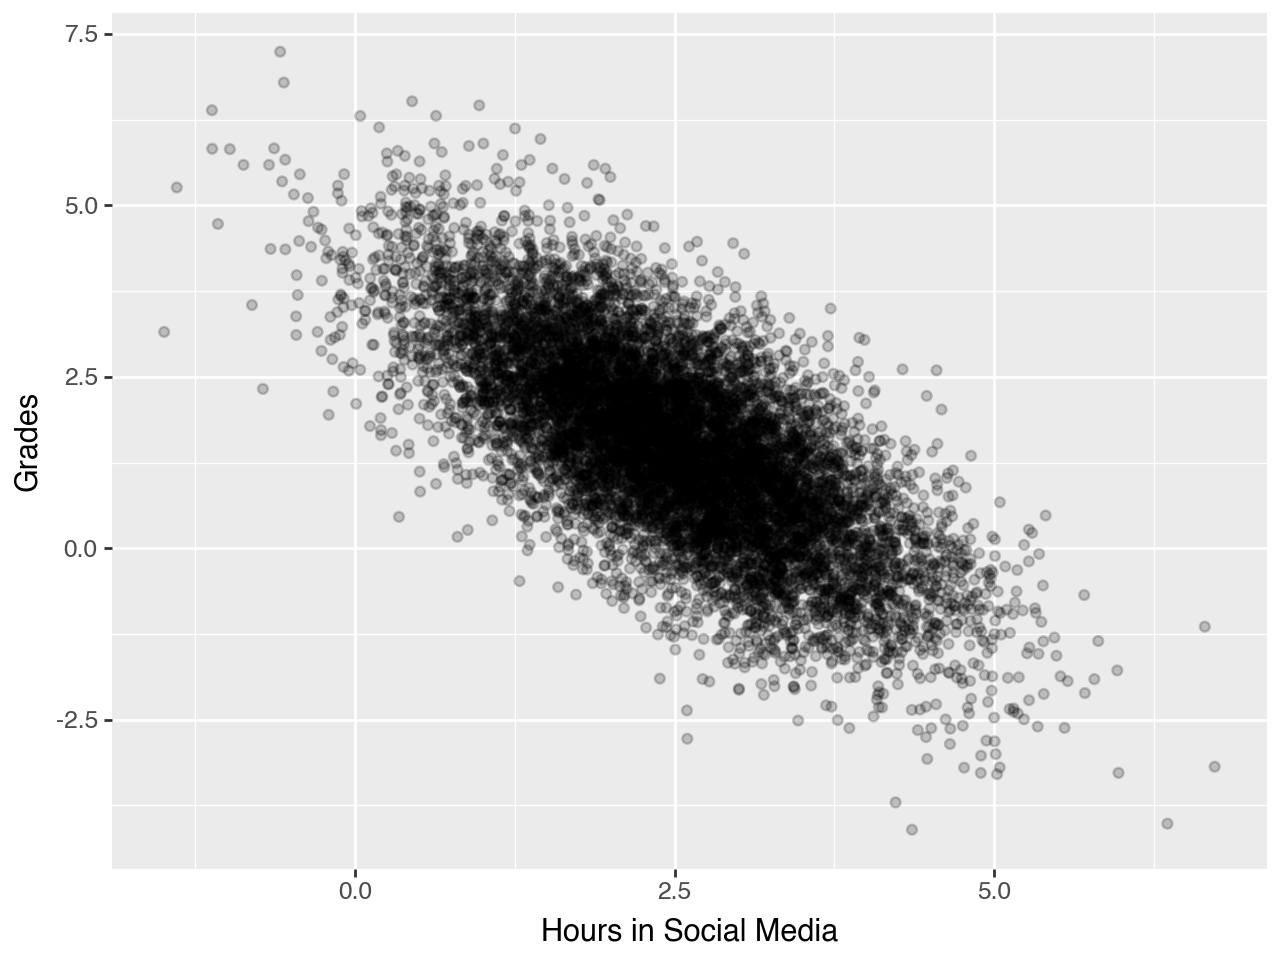

In [219]:
(
    ggplot(grade_media, aes('media_h', 'grades')) +
    geom_point(alpha = 0.2) + 
    labs(y = 'Grades', x = 'Hours in Social Media')
)

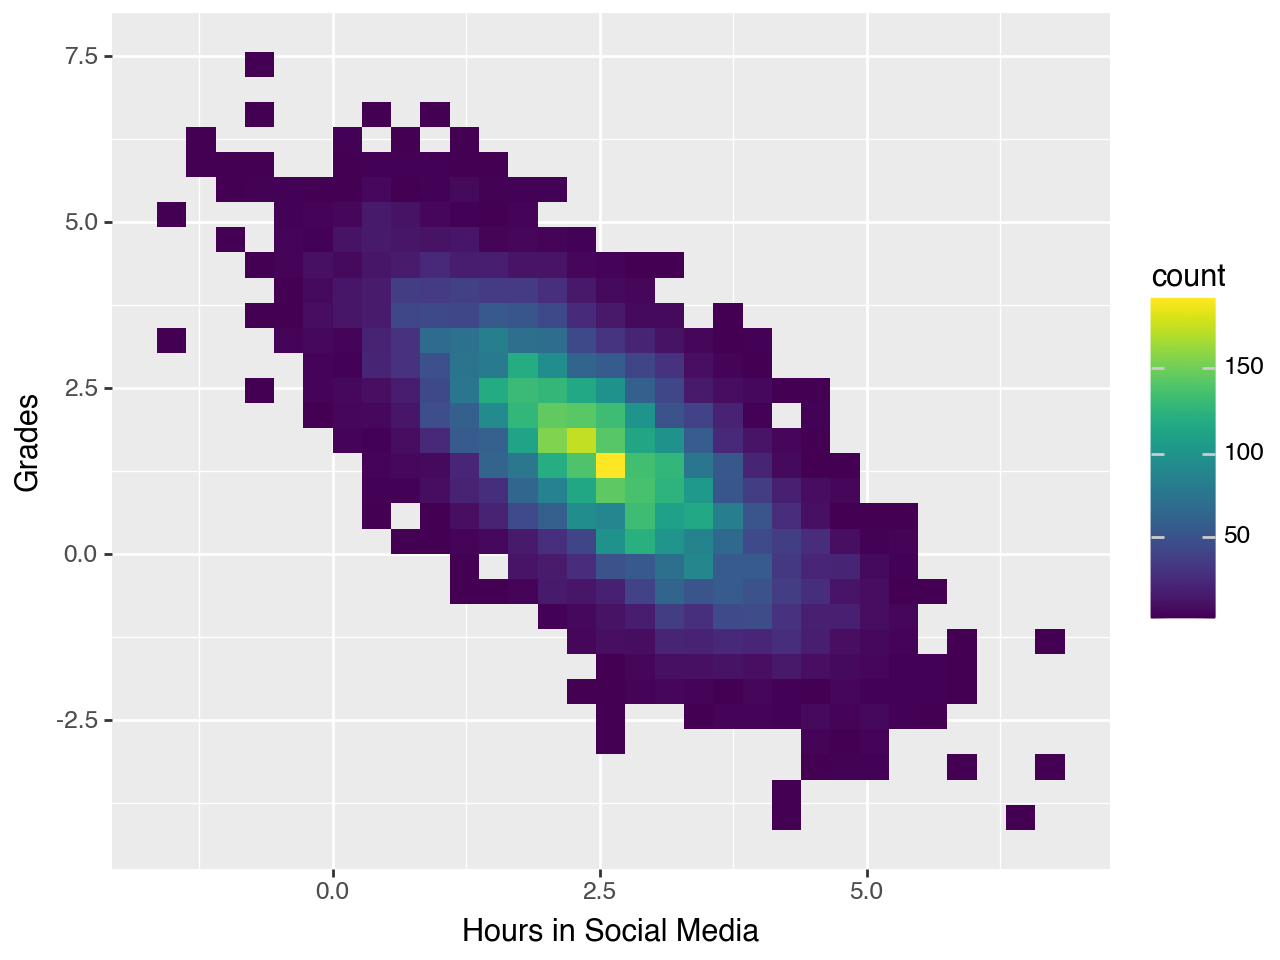

In [227]:
(
    ggplot(grade_media, aes('media_h', 'grades')) +
    geom_bin_2d(bins = 30) +  
    labs(y = 'Grades', x = 'Hours in Social Media')
)

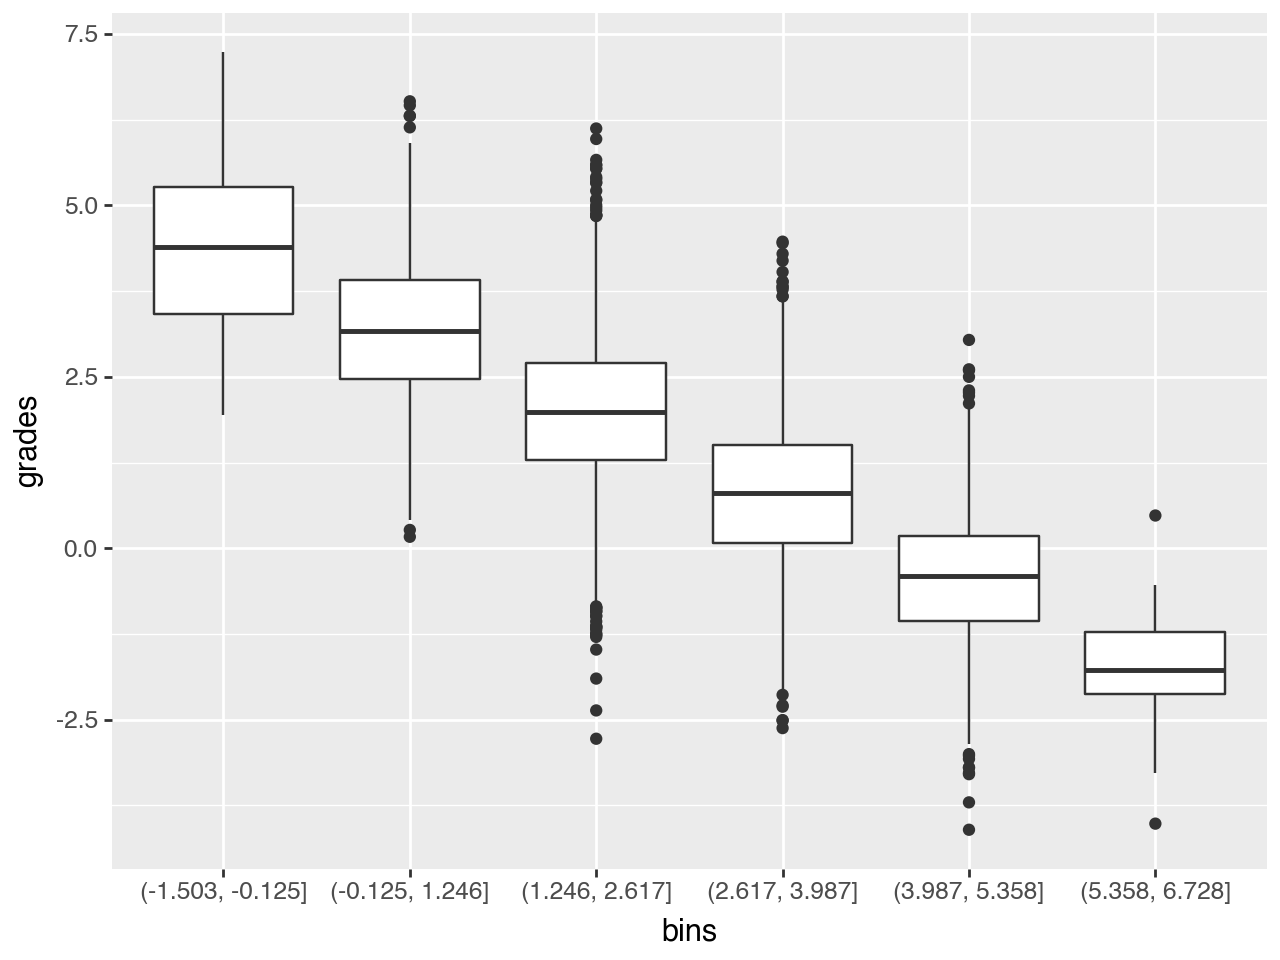

In [229]:
grade_media['bins'] = pd.cut(grade_media['media_h'], bins=6)
(
    ggplot(grade_media, aes(x='bins', y='grades')) +
    geom_boxplot()
)